# Język Python w Analizie Danych
# Lab07 - Wstęp do uczenia maszynowego - Sprawozdanie

Autor: Piotr Przymus 127902

In [21]:
# Import niezbędnych bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import modułów sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Zadanie 1
Wczytałem dane z pliku `data06_classification.csv` do `pandas.DataFrame`. Przeprowadziłem wstępną analizę (sprawdziłem braki danych, typy zmiennych).

In [22]:
df = pd.read_csv("data/data06_classification.csv")
print(df.info())
print(df.isnull().sum())

df = df.drop(columns=["ca", "thal"])

# uzupełnienie zmiennych numerycznych medianą
num_cols = ["trestbps", "chol", "thalch", "oldpeak"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# uzupełnienie zmiennych kategorycznych modą
cat_cols = ["fbs", "restecg", "exang", "slope"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Po uzupełnieniu braków danych:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB
None
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90

Kolumny `ca` oraz `thal` miały ponad 50% brakujących wartości, dlatego zostały usunięte. Pozostałe braki uzupełniłem: dla zmiennych numerycznych wykorzystałem medianę, a dla zmiennych kategorycznych najczęściej występującą wartość (modę). Po wykonaniu tych operacji zbiór danych nie zawierał brakujących wartości.

Zdefiniowałem zmienną celu (y) - zmienną `num` oraz cechy (X). W przypadku zmiennych tekstowych (np. 'sex'), zamieniłem je na wartości liczbowe.

In [23]:
X = df.drop(columns=["id", "num"])
y = df["num"]

X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(920, 18)


Podzieliłem zbiór na treningowy i testowy w proporcjach 80%/20%.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(736, 18)
(184, 18)


Wytrenowałem model `RandomForestClassifier` i dokonałem predykcji na zbiorze testowym.

In [25]:
from sklearn.ensemble import RandomForestClassifier

# trening
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# predykcja
y_pred = rf.predict(X_test)

Wyświetliłem raport klasyfikacji (classification_report) oraz macierz pomyłek (confusion_matrix). Przeanalizowałem, które cechy były najważniejsze dla modelu (atrybut feature_importances_).

Macierz pomyłek: 

[[68 10  4  0  0]
 [14 30  4  4  1]
 [ 4  6  7  5  0]
 [ 5  5  5  6  0]
 [ 0  2  1  3  0]]

Raport klasyfikacji: 

              precision    recall  f1-score   support

           0       0.75      0.83      0.79        82
           1       0.57      0.57      0.57        53
           2       0.33      0.32      0.33        22
           3       0.33      0.29      0.31        21
           4       0.00      0.00      0.00         6

    accuracy                           0.60       184
   macro avg       0.40      0.40      0.40       184
weighted avg       0.57      0.60      0.59       184

Cechy:

                 cecha   ważność
3               thalch  0.142119
0                  age  0.137144
2                 chol  0.132940
4              oldpeak  0.125453
1             trestbps  0.108978
15          exang_True  0.054840
6      dataset_Hungary  0.036707
9   cp_atypical angina  0.035669
10      cp_non-anginal  0.030669
5             sex_Male  0.029854


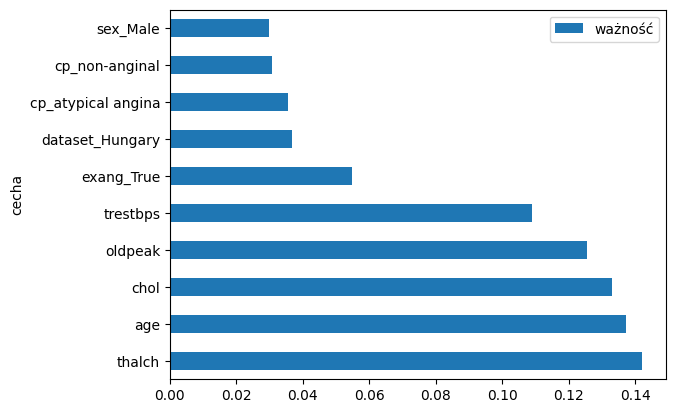

In [26]:
print("Macierz pomyłek: \n")
print(confusion_matrix(y_test, y_pred))

print("\nRaport klasyfikacji: \n")
print(classification_report(y_test, y_pred))

feature_importance = pd.DataFrame({
    "cecha": X.columns,
    "ważność": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="ważność",
    ascending=False
)

print("Cechy:\n")
feature_importance.head(10).plot(
    x="cecha",
    y="ważność",
    kind="barh"
)
print(feature_importance.head(10))

Model osiągnął dokładność około 60% na zbiorze testowym. Najlepsze wyniki uzyskano dla klasy 0, natomiast klasy o wyższych numerach były rozpoznawane znacznie słabiej, szczególnie klasa 4, dla której model nie uzyskał poprawnych predykcji. Może to wynikać z niezbalansowania danych oraz niewielkiej liczby obserwacji dla tej klasy.

Analiza ważności cech wykazała, że największy wpływ na predykcję miały zmienne takie jak `thalch`,  `age`, `chol`, `oldpeak` oraz `trestbps`. Wśród zmiennych kategorycznych istotne okazały się również `exang`, `cp` oraz `sex`.

Otrzymane wyniki wskazują, że model poprawnie wychwytuje ogólne zależności w danych, jednak jego skuteczność dla klas mniej licznych jest ograniczona.

### Zadanie 2
Wczytałem i przygotowałem dane z pliku `data/data06_regression.csv` (analogicznie do Zadania 1). Zmienną celu jest kolumna numeryczna `PerformanceIndex`.

In [27]:
df = pd.read_csv("data/data06_regression.csv")

print(df.info())
print(df.isnull().sum())

df = pd.get_dummies(df, columns=["Extracurricular Activities"], drop_first=True)
X = df.drop(columns=["Performance Index"])
y = df["Performance Index"]

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB
None
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


Podzieliłem dane na zbiór treningowy i testowy. Zastosowałem skalowanie danych przy pomocy `StandardScaler`.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(8000, 5) (2000, 5)


Dobirałem hiperparametry modeli `MLPRegressor`. Wytrenowałem modele i dokonałem predykcji na zbiorze testowym. Porównałem wyniki modeli z modelem o domyślnych hiperparametrach.

In [32]:
model1 = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)
model2 = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="tanh",
    solver="sgd",
    max_iter=1000,
    random_state=42
)
model_default = MLPRegressor(max_iter=1000, random_state=42)

# trening
model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
model_default.fit(X_train, y_train)

# predykcja
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)
y_pred_def = model_default.predict(X_test)

Wyznaczyłem i wyświetliłem następujące miary jakości modelu:
- MAE (Mean Absolute Error) – Średni błąd bezwzględny.
- MSE (Mean Squared Error) – Błąd średniokwadratowy.
- RMSE (Root Mean Squared Error) – Pierwiastek błędu średniokwadratowego.
- R2 (Współczynnik determinacji).

In [33]:
mae1 = mean_absolute_error(y_test, y_pred1)
mse1 = mean_squared_error(y_test, y_pred1)
rmse1 = np.sqrt(mse1)
r2_1 = r2_score(y_test, y_pred1)

mae2 = mean_absolute_error(y_test, y_pred2)
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)
r2_2 = r2_score(y_test, y_pred2)

mae3 = mean_absolute_error(y_test, y_pred_def)
mse3 = mean_squared_error(y_test, y_pred_def)
rmse3 = np.sqrt(mse3)
r2_3 = r2_score(y_test, y_pred_def)

# tabelka
results = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model Default"],
    "MAE": [f"{mae1:.2f}", f"{mae2:.2f}", f"{mae3:.2f}"],
    "MSE": [f"{mse1:.2f}", f"{mse2:.2f}", f"{mse3:.2f}"],
    "RMSE": [f"{rmse1:.2f}", f"{rmse2:.2f}", f"{rmse3:.2f}"],
    "R2": [f"{r2_1:.2f}", f"{r2_2:.2f}", f"{r2_3:.2f}"]
})
results

,Model,MAE,MSE,RMSE,R2
0,Model 1,1.64,4.22,2.05,0.99
1,Model 2,1.66,4.37,2.09,0.99
2,Model Default,1.66,4.33,2.08,0.99


Wszystkie modele osiągnęły wysoką jakość predykcji. Modele wyjaśniają niemal całą zmienność danych. Średni błąd predykcji jest bardzo niski, największy błąd występował dla modelu 2 - mogło to wynikać z tego że zastosowałem inny rodzaj solvera (SGD zamiast Adam) oraz inną funkcję aktywacji (tanh zamiast relu).

Wyniki wszystkich wariantów MLP są bardzo zbliżone - sugeruje to, że problem ma względnie prostą strukturę i sieci neuronowe są w stanie dobrze dopasować się do danych, nawet przy różnych konfiguracjach hiperparametrów.

Zwizualizowałem efekt działania regresji.

MLPRegressor: Rzeczywistość vs Predykcja


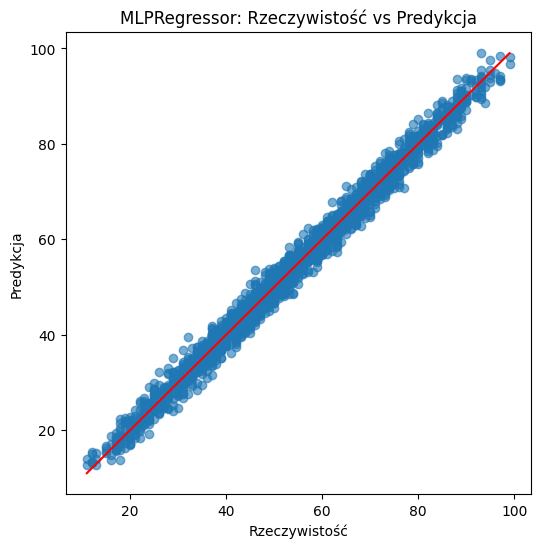

In [34]:
print("MLPRegressor: Rzeczywistość vs Predykcja")
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred1, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.xlabel("Rzeczywistość")
plt.ylabel("Predykcja")
plt.title("MLPRegressor: Rzeczywistość vs Predykcja")
plt.show()

Wykres pokazuje niemal idealne dopasowanie punktów do linii y = x, co potwierdza wysoką skuteczność modelu.

# Wnioski
Na podstawie obu zadań wyciągnąłem następujące wnioski:
- jakość modelu zależy zarówno od algorytmu, jak i charakterystyki danych,
- problemy klasyfikacyjne z niezbalansowanymi klasami są trudniejsze niż regresja na dobrze ustrukturyzowanych danych,
- odpowiednie przygotowanie danych (uzupełnianie braków, kodowanie, skalowanie) ma istotny wpływ na końcowy wynik modelu.